In [15]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from core.similarity import cosine_distances

In [16]:
import numpy as np

def test_shape():
    a = np.random.rand(5, 128)
    b = np.random.rand(3, 128)
    assert cosine_distances(a, b).shape == (5, 3)


def test_self_distance_is_zero():
    a = np.random.rand(4, 128)
    d = cosine_distances(a, a)
    assert np.allclose(np.diag(d), 0)


def test_opposite_vectors():
    a = np.array([[1.0, 0.0], [0.0, 1.0]])
    d = cosine_distances(a, -a)
    assert np.allclose(np.diag(d), 2)


def test_orthogonal():
    a = np.array([[1.0, 0.0]])
    b = np.array([[0.0, 1.0]])
    assert np.allclose(cosine_distances(a, b), 1)


if __name__ == "__main__":
    test_shape()
    test_self_distance_is_zero()
    test_opposite_vectors()
    test_orthogonal()
    print("all good")

all good


In [17]:
from pathlib import Path
from skimage import io

from core.normalize import resize_images

known_faces_dir = Path.cwd().parent / "known_faces"
image_extensions = {".jpg", ".jpeg", ".png"}

resize_images(known_faces_dir)

def load_image(img_path):
    image = io.imread(str(img_path))
    if image.shape[-1] == 4:
        image = image[..., :3]  # drop alpha channel
    return image

# Expected layout: known_faces/<person_name>/*.jpg
dataset_images = {
    person_dir.name: [
        load_image(img_path)
        for img_path in sorted(person_dir.iterdir())
        if img_path.suffix.lower() in image_extensions
    ]
    for person_dir in sorted(known_faces_dir.iterdir())
    if person_dir.is_dir()
}


In [18]:
from facenet_models import FacenetModel

model = FacenetModel()

detection_prob_threshold = 0.9  # min face-detection probability to keep a box

def get_descriptors(pic):
    boxes, probabilities, landmarks = model.detect(pic)
    if boxes is None:
        return []
    boxes = boxes[probabilities > detection_prob_threshold]
    if len(boxes) == 0:
        return []
    return list(model.compute_descriptors(pic, boxes))

# dataset: person_name -> list of shape-(512,) descriptor vectors
dataset = {
    person: [descriptor for pic in pics for descriptor in get_descriptors(pic)]
    for person, pics in dataset_images.items()
}


In [19]:
genuine = []
impostor = []
people = list(dataset.keys())
#cosine distances between every pair of same people
for person in people:
    descriptors = np.array(dataset[person])
    if len(descriptors) < 2:
        continue
    distance_matrix = cosine_distances(descriptors, descriptors)  # shape (n, n)
    # Take the upper triangle (k=1 skips the diagonal, which
    #    is always 0 since a descriptor's distance to itself is 0) so each
    #    same-person pair is only counted once.
    iu = np.triu_indices(len(descriptors), k=1)
    genuine.extend(distance_matrix[iu])
#between every pair of different people's descriptor arrays.
for i, person_a in enumerate(people):
    for person_b in people[i + 1:]:
        distance_matrix = cosine_distances(np.array(dataset[person_a]), np.array(dataset[person_b]))
        impostor.extend(distance_matrix.ravel())

genuine = np.array(genuine)
impostor = np.array(impostor)


#The following are two different ways to determine the threshold#



Plot/compare genuine vs. impostor distances. Pick the threshold that best separates them (e.g. where false-accept rate and false-reject rate cross).

threshold (FAR/FRR crossing): 0.2846
FAR at threshold: 0.0000, FRR at threshold: 0.0000


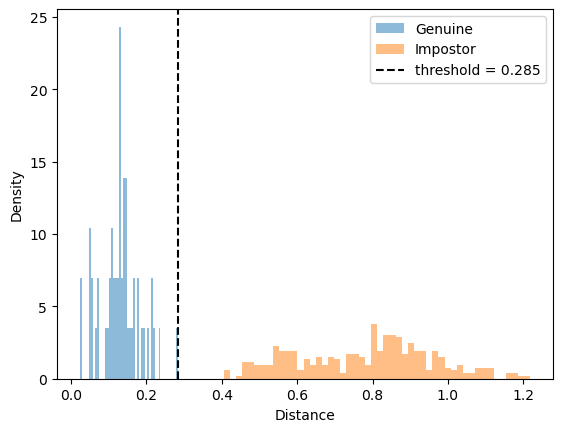

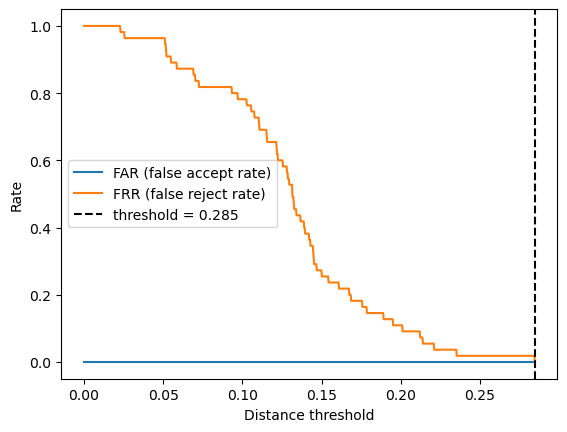

In [20]:
import matplotlib.pyplot as plt

# Sweep candidate thresholds and find where the false-accept rate (impostor
# pairs wrongly called a match) crosses the false-reject rate (genuine pairs
# wrongly called a non-match).
candidates = np.linspace(0, min(genuine.max(), impostor.max()), 1000)
far = np.array([(impostor <= t).mean() for t in candidates])
frr = np.array([(genuine > t).mean() for t in candidates])

crossing_idx = np.argmin(np.abs(far - frr))
threshold = candidates[crossing_idx]
print(f"threshold (FAR/FRR crossing): {threshold:.4f}")
print(f"FAR at threshold: {far[crossing_idx]:.4f}, FRR at threshold: {frr[crossing_idx]:.4f}")

plt.hist(genuine, bins=50, alpha=0.5, label="Genuine", density=True)
plt.hist(impostor, bins=50, alpha=0.5, label="Impostor", density=True)
plt.axvline(threshold, color="k", linestyle="--", label=f"threshold = {threshold:.3f}")
plt.xlabel("Distance")
plt.ylabel("Density")
plt.legend()
plt.show()

plt.plot(candidates, far, label="FAR (false accept rate)")
plt.plot(candidates, frr, label="FRR (false reject rate)")
plt.axvline(threshold, color="k", linestyle="--", label=f"threshold = {threshold:.3f}")
plt.xlabel("Distance threshold")
plt.ylabel("Rate")
plt.legend()
plt.show()

In [21]:
online_faces_dir = Path.cwd().parent / "online_faces" / "Online Faces"
online_paths = sorted(
    p for p in online_faces_dir.iterdir() if p.suffix.lower() in image_extensions
)

online_descriptors = []
kept_paths = []
for p in online_paths:
    descs = get_descriptors(load_image(p))
    if descs:
        online_descriptors.append(descs[0])  # one face expected per photo
        kept_paths.append(p)

online_descriptors = np.array(online_descriptors)
print(f"got descriptors for {len(online_descriptors)}/{len(online_paths)} online faces")


got descriptors for 30/30 online faces


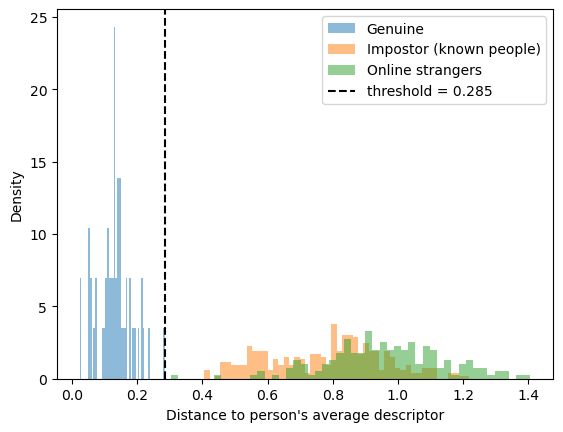


0 false accept(s) out of 30 strangers x 6 people
FAR against online strangers: 0.0000  (vs FAR against known impostors: 0.0000)


In [22]:
# Distance from every stranger to every known person's average descriptor
stranger_distances = {
    person: cosine_distances(online_descriptors, mean.reshape(1, -1)).ravel()
    for person, mean in person_mean.items()
}
all_stranger_dists = np.concatenate(list(stranger_distances.values()))

plt.hist(genuine, bins=50, alpha=0.5, label="Genuine", density=True)
plt.hist(impostor, bins=50, alpha=0.5, label="Impostor (known people)", density=True)
plt.hist(all_stranger_dists, bins=50, alpha=0.5, label="Online strangers", density=True)
plt.axvline(threshold, color="k", linestyle="--", label=f"threshold = {threshold:.3f}")
plt.xlabel("Distance to person's average descriptor")
plt.ylabel("Density")
plt.legend()
plt.show()

# Flag any stranger that would be falsely accepted as a known person
false_accepts = 0
for person, dists in stranger_distances.items():
    for idx in np.where(dists < threshold)[0]:
        false_accepts += 1
        print(f"FALSE ACCEPT: {kept_paths[idx].name} matched to {person} at distance {dists[idx]:.4f}")

stranger_far = (all_stranger_dists < threshold).mean()
print(f"\n{false_accepts} false accept(s) out of {len(kept_paths)} strangers x {len(person_mean)} people")
print(f"FAR against online strangers: {stranger_far:.4f}  (vs FAR against known impostors: {far[crossing_idx]:.4f})")
